# Figure S2 ALFA tag DASIT

In [10]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.ticker import ScalarFormatter
from pathlib import Path
import scipy
import seaborn as sns
from statannotations.Annotator import Annotator
import rushd as rd
import matplotlib
from scipy.optimize import curve_fit
from scipy.stats import poisson
from scipy.optimize import fsolve
from matplotlib.patches import Patch

# Nb(ALFA) results

In [11]:
# Directories
base_path = rd.datadir/'data'/'attune'/'Mary'
base_datadir = rd.datadir / 'data'/'attune'/"nat_attune" / "desNb-circuits"  / "2025.07.07_293T_DASIT-test_4dpi" / 'export'
cache_path = rd.rootdir/'output'/'Figure_S2_ALFA'/'data.gzip'
output_path = rd.rootdir/'output'/'Figure_S2_ALFA'


# Load data 
datadir = base_datadir/'test'
data = rd.flow.load_csv_with_metadata(datadir, datadir/'test_metadata.yaml')

# Get rid of negative data
data = data.loc[( data["TagBFP-A"] > 0) & (data["mRuby2-A"] > 0)]
data.to_parquet(rd.outfile(cache_path))

In [3]:
display(data)

,Target,Nb,well,population,FSC-A,FSC-H,FSC-W,SSC-A,SSC-H,SSC-W,...,TagBFP-A,TagBFP-H,TagBFP-W,mRuby2-A,mRuby2-H,mRuby2-W,YL2-A,YL2-H,YL2-W,Time
0,Ctrl-neg,<NA>,A12,Singlets,372778,213894,130,1517,929,0,...,14,78,0,142,132,0,54,57,0,0.020751
1,Ctrl-neg,<NA>,A12,Singlets,510345,266786,138,1691,924,0,...,136,72,0,1,57,0,-4,67,0,0.041502
4,Ctrl-neg,<NA>,A12,Singlets,190407,127274,109,1532,1228,16,...,37,63,0,107,65,0,0,41,0,0.085968
5,Ctrl-neg,<NA>,A12,Singlets,183808,116678,123,2170,1165,23,...,154,73,0,85,116,0,127,62,0,0.089921
6,Ctrl-neg,<NA>,A12,Singlets,413391,257507,132,1371,932,0,...,100,118,0,92,68,0,59,86,0,0.098814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
800010,TagBFP-ALFAx3,None,H6,Singlets,336353,196362,123,2292,1443,32,...,74,140,0,85,153,0,152,86,0,9.996430
800014,TagBFP-ALFAx3,None,H6,Singlets,161686,116224,123,1895,1409,23,...,79,57,0,120,124,0,59,58,0,9.997620
800015,TagBFP-ALFAx3,None,H6,Singlets,178941,130981,130,1394,970,0,...,4567,3385,41,124,93,0,-145,56,0,9.997620
800024,TagBFP-ALFAx3,None,H6,Singlets,479699,229557,140,3645,1992,42,...,921,748,0,225,168,0,120,61,0,9.998810


**Figure S2C ALFA Distributions**

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs

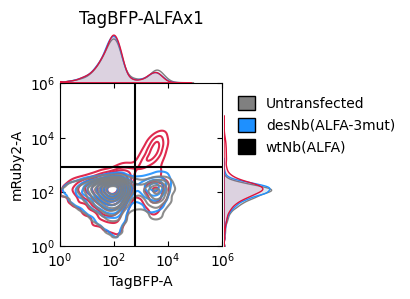

In [13]:
# Just look at TagBFPx1 ALFA
Target = 'TagBFP-ALFAx1'
small_data = data[data.Target == Target]
small_data = small_data.groupby('Nb').sample(n=10000) # Downsample

# General plotting params
x = "TagBFP-A"
y = "mRuby2-A"
hue = "Nb"
hue_order = ['wtNb(ALFA)', 'desNb(ALFA-3mut)', 'None']

# Conditions
palette = {
    'wtNb(ALFA)': 'black',
    'desNb(ALFA-3mut)': 'dodgerblue',
    'None': 'grey'
}

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(2.5, 2.5))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
ylim = mRuby2_lim
xlim = TagBFP_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=False,
)

legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=1,
          label='Untransfected'),
    Patch(facecolor='dodgerblue', edgecolor='black', linewidth=1,
          label='desNb(ALFA-3mut)'),
    Patch(facecolor='black', edgecolor='black', linewidth=1,
          label='wtNb(ALFA)')
]

ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

# Threshold
ax_scatter.axvline(TagBFP_A_thresh, 0, 1, color='black')
ax_scatter.axhline(mRuby2_A_thresh, 0, 1, color='black')

fig.tight_layout()  # Helps improve white spacing
ax_histx.set_title(Target) # Add plot label
plottitle = 'Figure_S2C_ALFA_contour.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')